# Sleep specific template

This is a template for analysing, cleaning, and extracting features for sleep data collected by wearables. It is recommended to first read the general template to understand the pipeline used here. In addition to the dataset specifications set out in the general template, this data should have a duration or end time column and a sleep stage column that should contain strings such as 'Deep', 'awake', 'REM' etc. There may also be columns for other metrics such as sleep efficiency, however this template is mainly focused on sleep stages data.

## Data Analysis

First, make all the neccesary imports and get the list of data files:

In [12]:
from IPython.display import display, HTML
import pandas as pd
import matplotlib.pyplot as plt
import calculate_durations
import all_field_summaries
import timestamps_check
import clean_and_extract_features
import helper_funcs
import os
import feature_extraction
import additional_funcs

# Set input variables
Folder_structure=1 # This should be either 1 or 2 (see above)
csv_name='active_apple_healthkit_sleep_stage' # The standard name for the csv that contains this data
site_list = ['test'] #The names of the subfolders for each site
input_folder = '//nasr.man.ac.uk/bmhrss$/snapped/replicated/CONNECT_study_data/data/test/passive-data/merged-data/' #The folder that contains all the site subfolders

#Get a list of the paths to each file to be included in this analysis
files_list=helper_funcs.get_file_paths(input_folder, csv_name,  Folder_structure,site_list)

3 files found


### Summarise_fields

For sleep data, this function is useful for seeing the full range of sleep stages incuded, so the sleep stages column name should be included in fields. You may also wish to include any other metrics such as efficiency to see if the range given is realistic.

If the data needs filtering, for example if there are other types of datapoints in the file, adjust the filter_dict dictionary and set the filter_dict variable in summarise_fields to filter_dictionary. 

In [13]:
#Edit this dictionary if you need to filter the data.
filter_dictionary = {
    # If you wish to only keep datapoints with certain values on specific rows, edit this
    # dictionary and set filter_dict in the function below to filter_dictionary. The keys
    # here are the names of the columns you want to filter by, and the values are the list
    # of acceptable entries for that column.
    "col1": [1, 3, 5],
    "col2": ['A', 'C'],
}

# Call Summarise_fields
df=all_field_summaries.Summarise_fields(
    files_list=files_list,
    time_stamp='value.time', #The name of the column that contains the timestamp.
    fields=['value.stringValue'], #We want to analyse 'value.stringValue' as this field reports sleep stages.
    filter_dict=None, # No filtering required
    df_adjustment_args=[None], # No adjustments neccesary for this data type.
    )

#Then display the results
df = df.round(2) # rounds the numbers for ease of viewing, may need to be adjusted depending on data.
html_table = df.to_html(index=False)  
styled_html = f"<div style='font-size:12px'>{html_table}</div>"
display(HTML(styled_html))

Field,Total,Values,Mean,Min,P1,LQT,median,UQT,P99,Max
value.stringValue,1381,"{'sleep.awake': 216, 'sleep.deep': 177, 'sleep.light': 567, 'sleep.rem': 253, 'sleep.inBed': 53, 'sleep': 115}",N/A,N/A,N/A,N/A,N/A,N/A,N/A,N/A


You can check that all the sleep stages given are meaningful and consider when any need to be filtered out of the rest of the analysis/feature extraction. This may need to be done in conjuction with a visual inspection of a few files. For example, we have found that active apple healthkit data has datapoints with 'sleep.inbed' in the sleep stage column and these datapoints always overlap with other datapoints. Therefore, this needs to be filtered out for the further analyses and feature extraction in this template, and analysed in a separate pipeline if required.

If you are also examining other metrics here and have sleep stages you do not want to include, you will need to repeat this function using the filter_dict variable to exclude these.

### investigate_frequency

This tool can give you an idea of how long each sleep stage lasts for and what the minimum duration appears to be. You would expect the time gaps to be similar to the durations, but also have bigger values for when there is data missing.

Again, you may wish to filter the data. In the below example we filter the sleep stages column to include all stages apart from 'sleep.inBed'

In [15]:
#Edit this if you need to filter the data
filter_dictionary = {
    # If you wish to only keep datapoints with certain values on specific rows, edit this
    # dictionary and set the filter_dict variable below to 'filter_dictionary'
    # The keys of this dictionary should be the names of the columns you want to filter by,
    # and the values should be a list of allowed values for that column (rows with any other 
    # values in this column will be filtered out)
    'value.stringValue': ['sleep.awake','sleep.light','sleep.rem','sleep.deep','sleep'],
}

#Run investigate_frequencies
df = calculate_durations.investigate_frequency(
    files_list = files_list,
    thresh = 1, # The threshold used when investigating closeness to mode.
    timestamp_col = 'value.time', # Name of timestamp column
    end_time_col = 'value.endTime', # Name of end time column.
    duration_col = None, # There is no duration column
    convert_to_unix = None, # The data is already in unix seconds
    filter_dict=filter_dictionary, # This is used to filter out datapoints reporting 'sleep.inbed'
    df_adjustment_args=[None], # No adjustments neccesary for this data type.
    )

#Display results
html_table = df.to_html(index=False)  
styled_html = f"<div style='font-size:14px'>{html_table}</div>"
display(HTML(styled_html))


,Mean,Median,Min,Max,Mode,number that are mode,number under mode (1 sec buffer),number close to mode (within 1 secs)
time gaps,3915.580377,748.0,1.0,726290.0,60.0,0.042264,0.046792,0.048302
durations,1971.040000,838.0,29.0,29400.0,60.0,0.043019,0.039245,0.049057


You can check whether the durations and time gaps seem sensible. You may which to experiment with different values of the variable 'thresh' to get an idea of the expected minimum time gap to inform choice of STG later. In this case, the number under mode went down considerably when the thresh was increased past 30, suggesting that 30 is the minimum expected gap, and therefore a suitable value for the STG. 

As well as checking the duration and gaps between each individual datapoint, you may also wish to check the size of 'blocks' of datatpoints. This is because in the feature extraction stage we assume that datapoints come in blocks (where one datapoint ends where the next one begins) corresponding to individual sleep episodes. To get an idea of whether your data follows this structure you can use the below code to see the distribution of 'block lengths'. To tailor this to another data type, adjust the following variables:

- time_stamp_col: The name of the timestamp column. This will be the start column if there is also an end time column.
- sleep_level_col: The name of the column that reports sleep level
- end_time_col: optional (default is None), set as the name of the end time column if one exists
- duration_col: optional (default is None), set as the name of the duration column if one exists
- convert_to_unix: optional (default is None), set to a list of columns that need converting to unix seconds if neccesary.
- filter_dict: optional (default is None), set this as 'filter_dictionary' and adjust the dictionary 'filter_dictionary' below if you wish to filter one or more fields


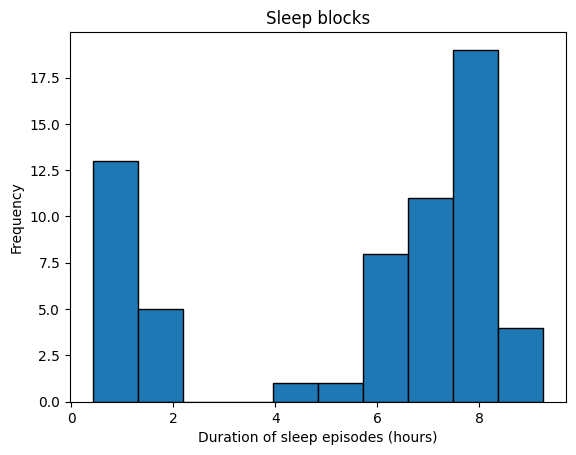

In [2]:
filter_dictionary = {
    #If you wish to only keep datapoints with certain values on specific rows, edit this
    # dictionary and set the filter_dict variable below to 'filter_dictionary'
    # The keys of this dictionary should be the names of the columns you want to filter by,
    # and the values should be a list of allowed values for that column (rows with any other values in this 
    # column will be filtered out)
    'value.stringValue': ['sleep.awake','sleep.light','sleep.rem','sleep.deep','sleep'],
}

all_block_durations=additional_funcs.investigate_sleep_blocks(
        files_list=files_list, 
        timestamp_col='value.time', # The timestamp column
        sleep_level_col='value.stringValue', # The column that reports sleep stages
        duration_col=None, # No duration column given
        end_time_col='value.endTime', # The end time column
        convert_to_unix=None, # This data is already in unix seconds
        filter_dict=filter_dictionary # This is used to remove datapoints with 'sleep.inBed' 
        )

plt.hist(all_block_durations, edgecolor='black')
# Add labels and title
plt.xlabel('Duration of sleep episodes (hours)')
plt.ylabel('Frequency')
#plt.xticks(range(0, 1401, 100))
plt.title('Sleep blocks')

# Show plot
plt.show()

If the duration peaks at roughly 8 hours this suggests that the data has the expected 'blocks' format.

### check_timestamp_errors

Next, we check the frequency of timestamp related errors in the data, see the general template for definitions.

The measurement_cols variable should include the sleep stage column, and any other metrics you are interested in.

In [16]:
filter_dictionary = {
    # If you wish to only keep datapoints with certain values on specific rows, edit this
    # dictionary and set the filter_dict variable below to 'filter_dictionary'
    # The keys of this dictionary should be the names of the columns you want to filter by,
    # and the values should be a list of allowed values for that column (rows with any other values in this 
    # column will be filtered out)
    'value.stringValue': ['sleep.awake','sleep.light','sleep.rem','sleep.deep','sleep'],
}

df=timestamps_check.check_timestamp_errors(
    files_list=files_list,
    EAS_threshold=5, # The threshold above which that datapoint will be counted as a EAS-OT.
    timegap_threshold=30, # The threshold below which a time gap will be counted as a STG
    measurement_cols=['value.stringValue'], # a list of all measurement columns to be included.
    timestamp_col='value.time', # Name of timestamp column
    end_time_col='value.endTime', # Name of end time column. 
    duration_col= None, # No duration column given for this data
    convert_to_unix = None, # This data is already in unix seconds
    filter_dict=filter_dictionary, # No fields need filtering so leave as None.
    df_adjustment_args=[None],# No adjustments neccesary for this data type.
    output_folder='//nasr.man.ac.uk/bmhrss$/snapped/replicated/CONNECT_study_data/2. Data exploration/Data_analysis_book_output_files/active_apple_healthkit_sleep_stages', # A folder where outputs are stored
    site_col='key.projectId', # Site column name
    participant_ID_col='key.userId' # participant ID column name
    )
html_table = df.to_html(index=False)  
styled_html = f"<div style='font-size:14px'>{html_table}</div>"
display(HTML(styled_html))

,total counts,fraction RT-CM,fraction RT+CM,fraction STG-CM,fraction STG+CM,fraction EAS,fraction EAS (over thresh)
All data,1328.0,0.0,0.0,0.0,0.005271,0.091114,0.091114
Maximum,1034.0,0.0,0.0,0.0,0.005803,0.100000,0.100000


If the frequency of timestamp errors is higher than acceptable, then you may wish to repeat with one column at a time in the measurements_col list to pinpoint the source of the issue. It may also be uesful to try leaving out the end time or duration column to investigate whether it is the measurement or duration that is changing for RT+CM and STG+CM. The files in the output folder can be useful for investigating these errors further and finding potential explanations. 


## Cleaning and feature extraction

### Conclusion
Here you can give a short summary of the above data analysis and any decisions made.

### Feature extraction and cleaning

The code presented here is designed for features calculated from the sleep stage column. We first use the standard cleaning and feature extraction function to produce a cleaned version of the data and the metadata features. For this, we use 'first' for the meas_agg variable, as the measurement values are strings so numeric methods such as 'mean' or 'sum' are not possible.

We next use the function get_sleep_features on the cleaned data to extract the following features:

- Total sleep time
- Number of sleep episodes
- Duration of longest sleep episode
- Number of awakenings in longest sleep episode
- Total duration of awake stages in longest sleep episode


This function requires the following variables to be set:

- timestamp_col: The timestamp/ start time column name
- sleep_stage_col: The name of the measurement column that reports sleep stage
- sleep_stages: A list of all the strings that occur in the sleep stage column that refer to a type of sleep (e.g 'light, 'rem, etc)
- awake_string: The string in the sleep stage column that represent awake periods
- interval: the interval required, supports 'D' for daily and 'h' for hourly'
- end_time_col: optional (default is None), set as the name of the end time column if one exists
- duration_col: optional (default is None), set as the name of the duration column if one exists


In [8]:
#TODO Add options for a range of input and output file structures and csv compressions
#TODO fix warning from sleep duration extraction function
output_folder = '//nasr.man.ac.uk/bmhrss$/snapped/replicated/CONNECT_study_data/analysis/model-development/1. Derived features/'
data_type='active_apple_healthkit_sleep_stage'
interval = 'D' # We want daily features

interval='D'
filter_dictionary = {
    # If you wish to only keep datapoints with certain values on specific rows, edit this
    # dictionary and set the filter_dict variable below to 'filter_dictionary'
    # The keys of this dictionary should be the names of the columns you want to filter by,
    # and the values should be a list of allowed values for that column (rows with any other values in this 
    # column will be filtered out)
    'value.stringValue': ['sleep.awake','sleep.light','sleep.rem','sleep.deep','sleep'],
}

for file_path in files_list:

    # Get ready to save output folder
    participant, site=helper_funcs.get_participant_and_site(file_path)
    os.makedirs(output_folder+site, exist_ok=True)
    os.makedirs(output_folder+site+'/'+participant, exist_ok=True) 

    # Read in the csv as a df
    try:
        if file_path[-3:]=='csv':
            df=pd.read_csv(file_path)
        if file_path[-3:]=='.gz':
            df=pd.read_csv(file_path, compression='gzip')
    except:
        print(file_path +' file cannot be read')   
        continue

    # Get cleaned version of the raw data and extract metadata features, then save to output folder
    cleaned_df, features = clean_and_extract_features.get_timestamp_errors_and_clean(
        df=df,
        interval=interval, 
        time_stamp_col='value.time', # The timestamp column
        measurement_col='value.stringValue', # The sleep stages column
        EAS_thresh=1,
        STG=30, # The STG value
        STG_fix=True, # We want to fix STG errors in the cleaned data files
        meas_agg='first', # Take the sleep stage of the first datapoint when cleaning RT+CM and STG+CM
        end_time_col='value.endTime', # The end time column
        duration_col=None, # No duration column needed
        convert_to_unix=None, # The data is already in unix seconds
        filter_dict=filter_dictionary, # We want to filter out 'sleep.inbed' from the sleep stages column
        included_errors=['RT+CM','STG-CM','STG+CM','EAS'] #Change from default to include EAS
    )

    # Extract features from cleaned_df
    if len(cleaned_df)>0:
        sleep_features=feature_extraction.get_sleep_features(
            cleaned_df, 
            timestamp_col='value.time', # The timestamp/ start time column name
            sleep_stage_col = 'value.stringValue', #The name of the measurement column that reports sleep stage
            awake_string='sleep.awake', # The string in the sleep stage column that represent awake periods
            sleep_stages=['sleep.rem','sleep.light', 'sleep.deep'], # A list of all non-awake sleep stages
            interval=interval, 
            end_time_col='value.endTime', # The end time column 
            duration_col=None, # There is no duration column
            )
        sleep_features.to_csv(output_folder+'/'+site+'/'+participant+'/'+data_type+'_'+interval+'_features.csv')

    # Save outputs
    cleaned_df.to_csv(output_folder+'/'+site+'/'+participant+'/'+data_type+'_cleaned.csv')
    features.to_csv(output_folder+'/'+site+'/'+participant+'/'+data_type+'_'+interval+'_metadata.csv')   
    

## Data availability

We can now use the metadata features we created to analyse how much data is available. We use the below code to look at the how many intervals (in this case days) have a non-zero amount of clean datapoints across all participants.

3 files found


Text(0.5, 1.0, 'Data availability across all participants')

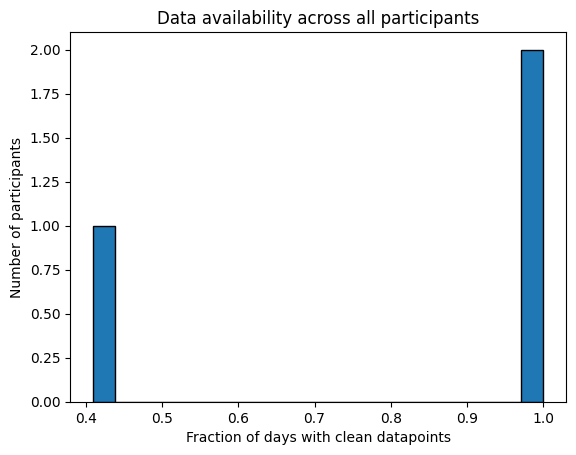

In [10]:
input_folder='//nasr.man.ac.uk/bmhrss$/snapped/replicated/CONNECT_study_data/analysis/model-development/1. Derived features/'
csv_name='active_apple_healthkit_sleep_stage_D_metadata'
files_list = helper_funcs.get_file_paths(input_folder, csv_name,  Folder_structure=2, site_list=site_list)

all_participants=[]
for path in files_list:
    df = pd.read_csv(path)
    df['total clean datapoints'] = df['total counts']-df['total timestamps with any error']
    all_participants.append(1-(len(df[df['total clean datapoints']==0])/len(df['total clean datapoints'])))

plt.hist(all_participants, bins = 20, edgecolor = 'black')
# Add labels and title
plt.xlabel('Fraction of days with clean datapoints')
plt.ylabel('Number of participants')
#plt.xticks(range(0.0, 1.0, 0.1))
plt.title('Data availability across all participants')